# 02 · Integrated phase-space + network-evolution

One narrative arc through the model's phase space, with the network's trust
structure visualised over time. Each section builds on the last.

Headline finding to look for: **with heterogeneous λ across the network,
low-λ "early-mover" agents flip first when the env drifts, then drag
high-λ neighbours along through trust dynamics — a Granovetter-style cascade
in active-inference clothing.**

## §0 · Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML

from src import (
    build, ModelConfig, EnvConfig, EvolutionRegime, History,
    fixed_layout, animate_population, static_strip,
)
import pymdp
from pymdp.agent import Agent as PymdpAgent

sns.set_theme(context='notebook', style='whitegrid')


def rollout_with_snapshots(model_cfg, env_cfg, T, snap_every=5):
    """Build (env, pop), roll out T steps, return (env_arrays, snapshots, final_pop)."""
    env, pop = build(model_cfg, env_cfg)
    h = History()
    h.snap(pop, every=snap_every)  # capture t=0
    for _ in range(T):
        pop, out = pop.step(env)
        h.append(out)
        h.snap(pop, every=snap_every)
    return h.as_arrays(), h.as_snapshots(), pop

In [ ]:
# Confirm the wrapper is still a real pymdp.Agent — for AIF reviewers scanning the code.
# The model state lives in pop.C / pop.q_post (multi-feature); pop.agent is a symbolic placeholder.
_, _pop = build(ModelConfig(n_agents=300, n_features=4, seed=0),
                EnvConfig(n_agents=300, n_features=4, seed=0))
print('pymdp version:    ', getattr(pymdp, '__version__', 'unknown'))
print('type(pop.agent):  ', type(_pop.agent).__name__)
print('isinstance pymdp.Agent:', isinstance(_pop.agent, PymdpAgent))
print('agent.batch_size: ', _pop.agent.batch_size)
print('agent.A is 2x2 identity:', bool(np.allclose(np.asarray(_pop.agent.A[0][0]), np.eye(2))))
print('pop.C shape (N, R):    ', tuple(_pop.C.shape))
print('pop.q_post shape:      ', tuple(_pop.q_post.shape))
print('pop.lambda_ shape:     ', tuple(_pop.lambda_.shape))
print('network kind:          ', _pop.cfg.network_kind)

## §1 · The phenomenon

Single rollout. Heterogeneous loose population (low-mean λ via Beta(3,7) on [0,2]).
Slow drift in `s_star` — the env's underlying "appropriate action" does a Bernoulli
random walk. Three panels: (a) ground-truth `s*` over time, (b) population mean
payoff, (c) variance across agents (which is high when the population is in flux).

In [ ]:
T = 300
N = 300
arrs, snaps, pop = rollout_with_snapshots(
    ModelConfig(
        n_agents=N, n_features=4,
        lambda_dist=('beta', {'alpha': 3.0, 'beta': 7.0, 'scale': 2.0}),
        seed=0,
    ),
    EnvConfig(
        n_agents=N, n_features=4,
        regime=EvolutionRegime.SLOW_DRIFT,
        drift_step_prob=0.04, seed=11,
    ),
    T, snap_every=5,
)

# Slow drift on all R features; pick feature 0 to illustrate.
s_star_traj = arrs['s_star'][:, 0]                # (T,)
payoffs     = arrs['payoffs']                      # (T, N)
mean_payoff = payoffs.mean(axis=1)
var_payoff  = payoffs.var(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
axes[0].step(np.arange(T), s_star_traj, where='post', lw=1.2, color='C2')
axes[0].set(ylabel='s*[φ_0]', yticks=[0, 1], ylim=(-0.2, 1.2),
            title='env ground truth (slow drift, feature 0)')
axes[1].plot(mean_payoff, lw=1.4, color='C0')
axes[1].set(ylabel='mean payoff', ylim=(0, 1.05))
axes[2].plot(var_payoff, lw=1.2, color='C3')
axes[2].set(xlabel='step', ylabel='payoff variance',
            title='heterogeneity signal — non-zero when population is mid-flip')
plt.tight_layout()
plt.show()

## §2 · Phase grid: λ-distribution mean × drift rate

Sweep both axes that the brief identifies as the relevant phase. λ-distribution
is `Beta(μ, 10−μ) × 10` so the mean is μ and there's always heterogeneity
(no degenerate constant-λ rows). Score is post-warmup tracking accuracy.

*Coarse 4×4 grid for notebook tractability; refine in a dedicated experiment
script for the paper.*

In [ ]:
import time
lambdas_mu = [0.5, 1.5, 3.0, 6.0]
drifts     = [0.005, 0.02, 0.08, 0.2]
n_seeds    = 3
T          = 200
warmup     = 50
N_grid     = 300

tracking = np.zeros((len(lambdas_mu), len(drifts)))
t0 = time.perf_counter()
for i, mu in enumerate(lambdas_mu):
    for j, drift in enumerate(drifts):
        scores = []
        for seed in range(n_seeds):
            arrs, _, _ = rollout_with_snapshots(
                ModelConfig(
                    n_agents=N_grid, n_features=4,
                    lambda_dist=('beta', {'alpha': mu, 'beta': 10.0 - mu, 'scale': 10.0}),
                    seed=seed,
                ),
                EnvConfig(
                    n_agents=N_grid, n_features=4,
                    regime=EvolutionRegime.SLOW_DRIFT,
                    drift_step_prob=drift, seed=200 + seed,
                ),
                T, snap_every=10**6,  # disable snapshots for speed
            )
            scores.append(arrs['payoffs'][warmup:].mean())
        tracking[i, j] = np.mean(scores)
print(f'phase grid: {time.perf_counter()-t0:.1f}s')

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    tracking, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0.4, vmax=1.0,
    xticklabels=drifts, yticklabels=lambdas_mu,
    cbar_kws={'label': 'tracking score (post-warmup mean payoff)'}, ax=ax,
)
ax.set(xlabel='drift_step_prob', ylabel='λ-distribution mean (Beta scaled)',
       title=f'Phase grid — slow-drift tracking, N={N_grid}, R=4')
plt.tight_layout()
plt.show()

## §3 · Heterogeneity matters — same mean λ, different distribution shapes

Holding the *mean* of λ roughly constant (~1.0), vary the *distribution shape*.
This isolates the cascade-from-heterogeneity story: a constant-λ population
behaves as one large agent; a broad or bimodal population can have early
movers that seed cascades.

Bands are mean ± 1 std across seeds.

In [ ]:
T = 200
n_seeds = 4
N_het = 300

configs = {
    'constant(1.0)':                ('constant', {'value': 1.0}),
    'uniform[0,2]':                  ('uniform', {'lo': 0.0, 'hi': 2.0}),
    'Beta(7,3)·2 (skewed-conservative)': ('beta', {'alpha': 7.0, 'beta': 3.0, 'scale': 2.0}),
    'bimodal(0.1,5.0,p=0.2) (innovators)': ('bimodal', {'low': 0.1, 'high': 5.0, 'p_low': 0.2}),
}

fig, ax = plt.subplots(figsize=(9, 4))
for label, spec in configs.items():
    runs = []
    for seed in range(n_seeds):
        arrs, _, _ = rollout_with_snapshots(
            ModelConfig(n_agents=N_het, n_features=4, lambda_dist=spec, seed=seed),
            EnvConfig(
                n_agents=N_het, n_features=4,
                regime=EvolutionRegime.SLOW_DRIFT,
                drift_step_prob=0.04, seed=300 + seed,
            ),
            T, snap_every=10**6,
        )
        runs.append(arrs['payoffs'].mean(axis=1))
    runs = np.stack(runs)
    mean = runs.mean(axis=0)
    std  = runs.std(axis=0)
    line, = ax.plot(mean, lw=1.5, label=label)
    ax.fill_between(np.arange(T), mean - std, mean + std, alpha=0.2, color=line.get_color())
ax.set(xlabel='step', ylabel='mean payoff', ylim=(0, 1.05),
       title=f'Same mean λ ≈ 1, four distribution shapes — slow drift, N={N_het}')
ax.legend(loc='lower right', fontsize=9, frameon=True)
plt.tight_layout()
plt.show()

## §4 · Cascade visualisation — per-agent trajectories coloured by λ

Bimodal population: 25% innovators (low λ) among 75% conservatives (high λ).
Each line is one agent's preference `σ(C[i, φ_0]) ∈ [0, 1]` over time, for
feature φ_0. Blue = low-λ (updates fast on this feature), red = high-λ
(entrenched). When `s*[φ_0]` flips, blue lines should cross 0.5 first; red
lines follow on a delay.

This rollout snapshots every step (we need full C trajectories) and is reused
in §5 — same dynamics, two views. With λ_scope='per_norm' agents have
independent stubbornness per feature; here we keep `per_agent` for the
clearest cascade visual.

In [ ]:
T = 300
N_cascade = 300
feature_idx = 0  # which feature to visualise (others evolve in parallel)

model_cfg_bimodal = ModelConfig(
    n_agents=N_cascade, n_features=4,
    lambda_dist=('bimodal', {'low': 0.2, 'high': 5.0, 'p_low': 0.25}),
    lambda_scope='per_agent',
    seed=7,
)
env_cfg_bimodal = EnvConfig(
    n_agents=N_cascade, n_features=4,
    regime=EvolutionRegime.SLOW_DRIFT,
    drift_step_prob=0.025, seed=42,
)

arrs_bm, snaps_bm, pop_bm = rollout_with_snapshots(
    model_cfg_bimodal, env_cfg_bimodal, T, snap_every=1,
)
# lambda_ has shape (N, R). With per_agent scope, all R columns are equal,
# so picking column [feature_idx] gives the per-agent λ for the cascade plot.
lambdas_per_agent = np.asarray(pop_bm.lambda_)[:, feature_idx]
C_history = np.stack([s['C'] for s in snaps_bm])         # (T+1, N, R)
# Agent's preference for φ_{feature_idx}=1 over time, on the [0, 1] scale.
preference = 1.0 / (1.0 + np.exp(-C_history[:, :, feature_idx]))  # (T+1, N)

from matplotlib import cm, colors as mcolors
norm = mcolors.LogNorm(vmin=lambdas_per_agent.min() + 1e-6, vmax=lambdas_per_agent.max())
agent_colours = cm.coolwarm(norm(lambdas_per_agent))

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                          gridspec_kw={'height_ratios': [1, 4]})
axes[0].step(np.arange(T), arrs_bm['s_star'][:, feature_idx], where='post', color='C2', lw=1.0)
axes[0].set(ylabel=f's*[φ_{feature_idx}]', yticks=[0, 1], ylim=(-0.2, 1.2),
            title=f'env ground truth, feature φ_{feature_idx}')
for i in range(N_cascade):
    axes[1].plot(preference[:, i], color=agent_colours[i], lw=0.4, alpha=0.5)
axes[1].axhline(0.5, ls='--', c='black', lw=0.5)
axes[1].set(xlabel='step', ylabel=f'σ(C[i, φ_{feature_idx}])', ylim=(0, 1),
            title=f'per-agent preference on φ_{feature_idx}, coloured by λ '
                  '(blue = low/loose, red = high/conservative)')
sm = cm.ScalarMappable(norm=norm, cmap='coolwarm')
sm.set_array([])
fig.colorbar(sm, ax=axes[1], label='λ_i (log)', pad=0.01)
plt.tight_layout()
plt.show()

## §5 · Network evolution — see the dissent front spread on the scale-free graph

Reuse the bimodal rollout from §4 (downsampled for animation tractability).
At N=300, the Barabási–Albert graph has a power-law degree distribution —
spring layout will render this as visible hub clusters. Node colour =
`σ(C[:, φ_0])` (preference on feature 0 in [0, 1]); edge colour and
thickness = `γ_ij` (live trust on each edge).

Three views: static strip → animation → γ-norm scalar time series.

In [7]:
# downsample snaps_bm to every 5th frame for the animation
snaps_anim = snaps_bm[::5]
adj = np.asarray(pop_bm.A_adj)
layout = fixed_layout(adj, seed=0)
print(f'snapshots for viz: {len(snaps_anim)}  (every 5 steps over {T})')

snapshots for viz: 61  (every 5 steps over 300)


In [ ]:
# Cell 5a: static strip — paper-ready figure
fig = static_strip(
    snaps_anim, adj, layout,
    indices=[0, len(snaps_anim) // 3, 2 * len(snaps_anim) // 3, len(snaps_anim) - 1],
    node_metric_key='preference',
    feature_idx=0,
    node_size=35.0,  # smaller dots for N=300
)
fig.suptitle(f'Network evolution: nodes coloured by σ(C[:, φ_0]), edges by γ_ij  (N={N_cascade})',
             y=1.02)
plt.show()

In [ ]:
# Cell 5b: inline scrubbable animation
anim = animate_population(
    snaps_anim, adj, layout,
    node_metric_key='preference',
    feature_idx=0,
    interval_ms=160,
    figsize=(7, 7),
    node_size=35.0,
)
HTML(anim.to_jshtml())

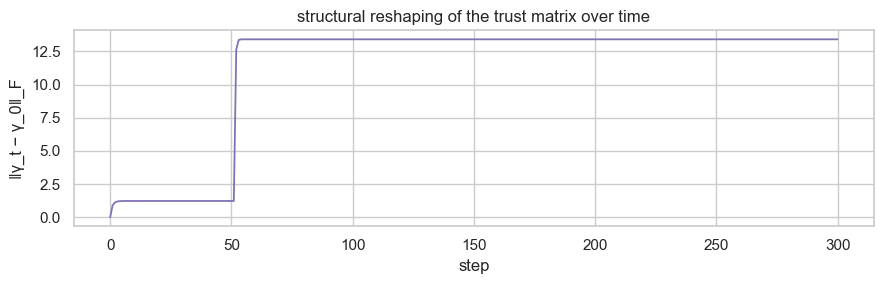

In [10]:
# Cell 5c: γ-norm time series — single number for trust-network reshaping
gamma_history = np.stack([s['gamma'] for s in snaps_bm])     # (T+1, N, N)
gamma0 = gamma_history[0]
drift_norm = np.linalg.norm(gamma_history - gamma0[None], axis=(1, 2), ord='fro')

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(drift_norm, lw=1.3, color='C4')
ax.set(xlabel='step', ylabel='‖γ_t − γ_0‖_F',
       title='structural reshaping of the trust matrix over time')
plt.tight_layout()
plt.show()

## §6 · What we'd need next

- **Heterogeneous `d`** — currently d ∼ Beta(7,3) for everyone but the
  parameter is in the same family as λ. Independent thinkers (low d) are
  another route to cascade seeding.
- **Network position analysis** — do hub agents (high in-degree) cascade
  differently than periphery agents? `nx.degree_centrality` on the
  trust-weighted graph would surface this.
- **Forward vs reverse drift trajectories** — the headline hysteresis loop
  area in (λ-mean, drift-rate) space. Run the same env trajectory forward
  and reverse, plot population payoff against `s_star` direction.
- **Rule-induction baseline (E4 in the brief)** — clean dissociation from
  Bayesian rule-induction (Oldenburg & Zhi-Xuan 2024) is the headline
  comparison point. Separate model, separate notebook.
- **GPU vmap-over-seeds** — once we've nailed the figures, batching seeds
  through a `lax.scan` + `vmap` rollout enables Colab GPU sweeps. Pattern
  in `C:\GitHub\Collective Intelligence Library\experiments\basin_stability`.